# Final Project

## Project Description
The goal of this project is to make an interactive Python tool that allows the user to explore statistical relationships between Alzheimer’s disease and potential contributing factors.
Alzheimer's disease is a neurodegenerative disorder that slowly damages memory, the ability to think, and behavior. Due to the effects it has on individuals, it has become an increasing concern in especially older populations. Researchers believe that there are many different causes that may contribute to developing Alzheimer’s, including genetics, age, lifestyle choices, and much more. By analyzing large datasets and noticing patterns, individuals can better understand what might contribute to Alzheimer’s disease and how the relationships interact. In our project, we will allow for a user to analyze a public Alzheimer’s disease dataset to better understand correlation between different lifestyle variables.

#### References (*if applicable*)
Kaggle. Alzheimer’s Disease Dataset. Retrieved from https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

## Team Contributions
* Aria Wang: Setup, load dataset, clean data, display available columns, prompt user for feature selection
* Anderson Hoang:
* Treasa Paul: plot creation, visualization, and explanations

<hr>

## Setup
*This is where you can import modules as needed. You can remove this step if is not required for your project.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Main Code
*Add as many code blocks as you need here, with a combination of documentation via in-line comments, in-block comments, and markdown cells to explain what the code is doing.*
*If you are choosing to put your code into a module, you can use this markdown cell to explain, and the cell below to run your module.*

In [2]:
# Load dataset
df = pd.read_csv("alzheimers_disease_data.csv")

In [3]:
# View all column names
list(df.columns)

['PatientID',
 'Age',
 'Gender',
 'Ethnicity',
 'EducationLevel',
 'BMI',
 'Smoking',
 'AlcoholConsumption',
 'PhysicalActivity',
 'DietQuality',
 'SleepQuality',
 'FamilyHistoryAlzheimers',
 'CardiovascularDisease',
 'Diabetes',
 'Depression',
 'HeadInjury',
 'Hypertension',
 'SystolicBP',
 'DiastolicBP',
 'CholesterolTotal',
 'CholesterolLDL',
 'CholesterolHDL',
 'CholesterolTriglycerides',
 'MMSE',
 'FunctionalAssessment',
 'MemoryComplaints',
 'BehavioralProblems',
 'ADL',
 'Confusion',
 'Disorientation',
 'PersonalityChanges',
 'DifficultyCompletingTasks',
 'Forgetfulness',
 'Diagnosis',
 'DoctorInCharge']

In [4]:
# Clean data and drop unnecessary columns
def clean_data(df):
    """
    Remove identifier and clinical scoring columns that are
    not needed for lifestyle correlation analysis.
    """
    df = df.drop(columns=["PatientID","DoctorInCharge","MMSE","FunctionalAssessment","ADL"])
    return df

df_clean = clean_data(df)
df_clean.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,CholesterolHDL,CholesterolTriglycerides,MemoryComplaints,BehavioralProblems,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,33.682563,162.189143,0,0,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,79.028477,294.630909,0,0,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,69.772292,83.638324,0,0,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,68.457491,277.577358,0,1,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,56.874305,291.198780,0,0,0,0,1,1,0,0


In [5]:
# Show all available columns in a list
list(df_clean.columns)

['Age',
 'Gender',
 'Ethnicity',
 'EducationLevel',
 'BMI',
 'Smoking',
 'AlcoholConsumption',
 'PhysicalActivity',
 'DietQuality',
 'SleepQuality',
 'FamilyHistoryAlzheimers',
 'CardiovascularDisease',
 'Diabetes',
 'Depression',
 'HeadInjury',
 'Hypertension',
 'SystolicBP',
 'DiastolicBP',
 'CholesterolTotal',
 'CholesterolLDL',
 'CholesterolHDL',
 'CholesterolTriglycerides',
 'MemoryComplaints',
 'BehavioralProblems',
 'Confusion',
 'Disorientation',
 'PersonalityChanges',
 'DifficultyCompletingTasks',
 'Forgetfulness',
 'Diagnosis']

In [6]:
# Symptom variables representing clinical outcomes
symptom_columns = ["MemoryComplaints","BehavioralProblems","Confusion","Disorientation","PersonalityChanges",
                   "DifficultyCompletingTasks","Forgetfulness"]

In [7]:
# X variables: potential contributing factors (lifestyle + demographics + health indicators)
x_options = [col for col in df_clean.columns if col not in symptom_columns + ["Diagnosis"]]

# Y variables: possible outcomes (diagnosis or symptoms)
y_options = symptom_columns + ["Diagnosis"]

In [8]:
# Print tool introduction
print("=== Alzheimer’s Data Exploration Tool ===\n")
print("This tool helps explore statistical relationships between potential health/lifestyle factors")
print("and Alzheimer’s disease outcomes (diagnosis or symptoms).\n")

=== Alzheimer’s Data Exploration Tool ===

This tool helps explore statistical relationships between potential health/lifestyle factors
and Alzheimer’s disease outcomes (diagnosis or symptoms).



In [9]:
# Select X variables (contributor) for analysis
def select_x(x_options):
    """
    Prompt the user to select two contributor variables (X)
    and validate the selections.
    """
    # Show available X variables
    print("\nStep 1: Select CONTRIBUTOR variables (X)")
    print("Choose TWO variables to compare against an Alzheimer's outcome.")
    print("Available X variables:")
    print(", ".join(x_options))

    while True:
        # Prompt the user to select X variables
        x_input = input("\nEnter two X variables separated by comma:\n")

        # Parse input
        x_vars = [x.strip() for x in x_input.split(",")]

        # Validate input
        valid_x = [x for x in x_vars if x in x_options]
        invalid_x = set(x_vars) - set(valid_x)

        # Feedback for invalid inputs
        if invalid_x:
            print("\nWarning: These variables are not valid and will be ignored:", invalid_x)

        # Require at least two valid variables
        if len(valid_x) < 2:
            print("Please enter at least two valid X variables.")
            continue

        # If more than two valid variables are entered, keep only the first two
        if len(valid_x) > 2:
            print("More than two valid variables entered. Using the first two.")
            valid_x = valid_x[:2]

        return valid_x

In [10]:
# Select Y variable (outcome) for analysis
def select_y(y_options):
    """
    Prompt the user to select one outcome variable (Y)
    and validate the selection.
    """
    print("\nStep 2: Select OUTCOME variable (Y)")
    print("Available Y variables:")
    print(", ".join(y_options))

    # Prompt the user to select one Y variable
    y_var = input("\nEnter ONE Y variable:\n").strip()

    # If the input is invalid, default to Diagnosis
    if y_var not in y_options:
        print("Invalid selection. Defaulting to Diagnosis.")
        y_var = "Diagnosis"

    return y_var

In [11]:
def feature_selection(x_options, y_options):
    """
    Run the interactive feature selection process and return
    the selected X variables and Y variable.
    """
    # Introduction to the tool
    print("\n=== Alzheimer’s Data Exploration Tool ===")
    print("Explores relationships between health factors and Alzheimer’s outcomes.\n")

    # Call function to select X variables
    x_vars = select_x(x_options)

    # Call function to select Y variable
    y_var = select_y(y_options)

    # Display final selections
    print("\nFeature selection complete.")
    print("X variables:", x_vars)
    print("Y variable:", y_var)

    # Return selections for later analysis steps
    return x_vars, y_var

In [21]:
def analyze_data(df, x_vars, y_var):

    """
    Analyzes the relationship between selected predictor variables
    and an outcome variable.

    For binary outcomes:
        - Calculates correlations
        - Fits a Logistic Regression model
        - Reports strongest predictors

    For continuous outcomes:
        - Calculates correlations
        - Fits a Linear Regression model
        - Reports R²
        - Reports strongest predictors

    Returns:
        Regression model
    """

    data = df[x_vars + [y_var]].dropna()

    X = pd.get_dummies(data[x_vars], drop_first=True)
    y = data[y_var]

    print()
    print("===", y_var, "Analysis ===")

    # Correlations

    correlations = {}

    for variable in X.columns:
        correlations[variable] = X[variable].corr(y)

    correlation_list = list(correlations.items())

    sorted_correlations = []

    while len(correlation_list) > 0:

        largest = correlation_list[0]

        for item in correlation_list:
            if abs(item[1]) > abs(largest[1]):
                largest = item

        sorted_correlations.append(largest)
        correlation_list.remove(largest)

    correlation_list = sorted_correlations

    print()
    print("Top Relationships:")

    count = 0

    for variable, corr in correlation_list:

        if abs(corr) < 0.10:
            strength = "Very Weak"
        elif abs(corr) < 0.30:
            strength = "Weak"
        elif abs(corr) < 0.50:
            strength = "Moderate"
        else:
            strength = "Strong"

        print(variable, ":", round(corr, 3), "(", strength, ")")

        count = count + 1

        if count == 5:
            break

    # Determine outcome type

    unique_values = set(y)

    if len(unique_values) <= 2:

        print()
        print(y_var, "is binary (Yes/No outcome).")

        model = LogisticRegression(max_iter=1000)
        model.fit(X, y)

        coefficients = []

        column_names = list(X.columns)
        coefs = model.coef_[0]

        index = 0

        while index < len(column_names):
            coefficients.append((column_names[index], coefs[index]))
            index = index + 1

        sorted_coefficients = []

        while len(coefficients) > 0:

            largest = coefficients[0]

            for item in coefficients:
                if abs(item[1]) > abs(largest[1]):
                    largest = item

            sorted_coefficients.append(largest)
            coefficients.remove(largest)

        coefficients = sorted_coefficients

        print()
        print("Strongest Predictors:")

        count = 0

        for variable, coef in coefficients:

            if coef > 0:
                direction = "higher"
            else:
                direction = "lower"

            print(variable, ":", direction, "likelihood of", y_var)

            count = count + 1

            if count == 5:
                break

        print()
        print("Summary:")
        print("The variables above show the strongest relationships with the selected outcome. Larger coefficients indicate stronger associations.")

    else:

        print()
        print(y_var, "is continuous (numeric outcome).")

        model = LinearRegression()
        model.fit(X, y)

        predictions = model.predict(X)
        r2 = r2_score(y, predictions)

        print()
        print("R² =", round(r2, 3))

        if r2 < 0.10:
            print("The selected variables explain very little of the variation in the outcome.")
        elif r2 < 0.30:
            print("The selected variables explain a small portion of the variation in the outcome.")
        else:
            print("The selected variables explain a meaningful portion of the variation in the outcome.")

        coefficients = []

        column_names = list(X.columns)
        coefs = model.coef_

        index = 0

        while index < len(column_names):
            coefficients.append((column_names[index], coefs[index]))
            index = index + 1

        sorted_coefficients = []

        while len(coefficients) > 0:

            largest = coefficients[0]

            for item in coefficients:
                if abs(item[1]) > abs(largest[1]):
                    largest = item

            sorted_coefficients.append(largest)
            coefficients.remove(largest)

        coefficients = sorted_coefficients

        print()
        print("Strongest Predictors:")

        count = 0

        for variable, coef in coefficients:

            if coef > 0:
                direction = "increase"
            else:
                direction = "decrease"

            print(variable, ": tends to", direction, y_var)

            count = count + 1

            if count == 5:
                break

        print()
        print("Summary:")
        print("An R² value of", round(r2, 3), "means approximately", round(r2 * 100, 1), "% of the variation in", y_var, "can be explained by the selected variables.")

    print()
    print("Important: Correlation and regression identify associations but do not prove causation.")

    return model

In [22]:
x_vars, y_var = feature_selection(x_options, y_options)
model = analyze_data(df_clean, x_vars, y_var)


=== Alzheimer’s Data Exploration Tool ===
Explores relationships between health factors and Alzheimer’s outcomes.


Step 1: Select CONTRIBUTOR variables (X)
Choose TWO variables to compare against an Alzheimer's outcome.
Available X variables:
Age, Gender, Ethnicity, EducationLevel, BMI, Smoking, AlcoholConsumption, PhysicalActivity, DietQuality, SleepQuality, FamilyHistoryAlzheimers, CardiovascularDisease, Diabetes, Depression, HeadInjury, Hypertension, SystolicBP, DiastolicBP, CholesterolTotal, CholesterolLDL, CholesterolHDL, CholesterolTriglycerides



Enter two X variables separated by comma:
 Gender, Hypertension



Step 2: Select OUTCOME variable (Y)
Available Y variables:
MemoryComplaints, BehavioralProblems, Confusion, Disorientation, PersonalityChanges, DifficultyCompletingTasks, Forgetfulness, Diagnosis



Enter ONE Y variable:
 Diagnosis



Feature selection complete.
X variables: ['Gender', 'Hypertension']
Y variable: Diagnosis

=== Diagnosis Analysis ===

Top Relationships:
Hypertension : 0.035 ( Very Weak )
Gender : -0.021 ( Very Weak )

Diagnosis is binary (Yes/No outcome).

Strongest Predictors:
Hypertension : higher likelihood of Diagnosis
Gender : lower likelihood of Diagnosis

Summary:
The variables above show the strongest relationships with the selected outcome. Larger coefficients indicate stronger associations.

Important: Correlation and regression identify associations but do not prove causation.


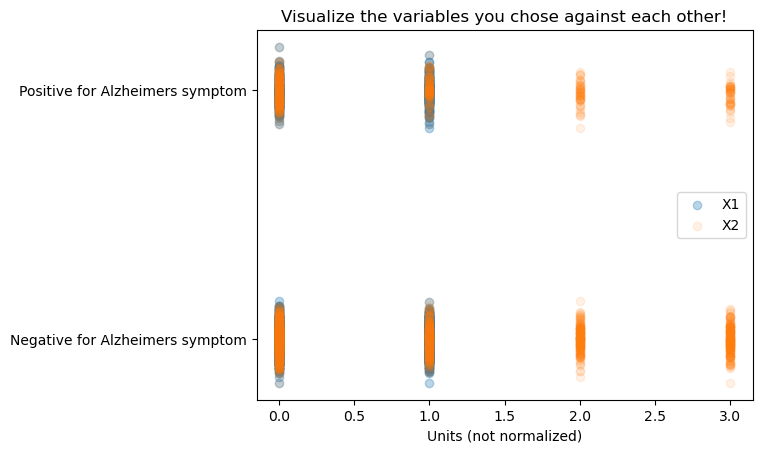

Here's a graph comparing the two x-values you chose to the y-value you chose! Blue points refer to the first x-value you chose
and orange points are data from the second x-value! You can also see which points belonged to patients who also marked positive
for the Alzheimers' symptom or diagnosis you selected. Note that this visualization is most helpful if you are choosing variables
that are not on a binary scale and rather have a range of values.
Thanks for using our application to help analyze Alzheimers' data!


In [20]:
'''redo steps in order to save X and y values'''
''' Keep selected columns'''
analysis_df = df[x_vars + [y_var]].copy()

''' Remove missing values '''
analysis_df = analysis_df.dropna()

''' Convert categorical variables into numeric form '''
analysis_df = pd.get_dummies(
    analysis_df,
    drop_first=True
)

''' Separate X and Y '''
X = analysis_df.drop(columns=[y_var])
y = analysis_df[y_var]

'''separate X into each part for plotting'''
X1 = X.iloc[:, 0]
X2 = X.iloc[:, 1]

'''use jitter to create some variance to better visualize with the naked eye (this is still kind of tough to see for values that only contain 0 or 1 answers'''
y_jitter = y + np.random.normal(0, 0.05, len(y))
'''create the plot using matplotlib and change the opacity of the points so they are more differentiable'''
plt.scatter(X1, y_jitter, alpha=0.3, label = 'X1')
plt.scatter(X2, y_jitter, alpha=0.1, label = 'X2')
'''customizing the plot'''
plt.yticks([0,1], ['Negative for Alzheimers symptom','Positive for Alzheimers symptom'])
plt.title('Visualize the variables you chose against each other!')
plt.xlabel('Units (not normalized)')
plt.legend()
plt.show()

print ("Here's a graph comparing the two x-values you chose to the y-value you chose! Blue points refer to the first x-value you chose")
print ("and orange points are data from the second x-value! You can also see which points belonged to patients who also marked positive")
print ("for the Alzheimers' symptom or diagnosis you selected. Note that this visualization is most helpful if you are choosing variables")
print ("that are not on a binary scale and rather have a range of values.")
print ("Thanks for using our application to help analyze Alzheimers' data!")